In [2]:
# Section 1 — Environment and Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fredapi import Fred
from dotenv import load_dotenv
import os

# Load API key from .env file
load_dotenv('../.env')
fred = Fred(api_key=os.getenv('FRED_API_KEY'))

# Define sample date range
START_DATE = '2003-01-01'
END_DATE = '2024-12-31'

print(f"Sample period: {START_DATE} to {END_DATE}")
print("Environment loaded successfully")

Sample period: 2003-01-01 to 2024-12-31
Environment loaded successfully


In [4]:
import time

# SECTION 2 — PULL ALL RAW SERIES

# --- 10-Year Treasury Yield ---
dgs10_raw = fred.get_series('DGS10', START_DATE, END_DATE)
print(f"DGS10: {dgs10_raw.shape[0]} obs, {dgs10_raw.isna().sum()} nulls")
print(f"  Range: {dgs10_raw.index.min()} to {dgs10_raw.index.max()}")
time.sleep(1)

# --- ACM Term Premium ---
term_premium_raw = fred.get_series('THREEFYTP10', START_DATE, END_DATE)
print(f"THREEFYTP10: {term_premium_raw.shape[0]} obs, {term_premium_raw.isna().sum()} nulls")
print(f"  Range: {term_premium_raw.index.min()} to {term_premium_raw.index.max()}")
time.sleep(1)

# --- Fed Funds Rate ---
fedfunds_raw = fred.get_series('FEDFUNDS', START_DATE, END_DATE)
print(f"FEDFUNDS: {fedfunds_raw.shape[0]} obs, {fedfunds_raw.isna().sum()} nulls")
print(f"  Range: {fedfunds_raw.index.min()} to {fedfunds_raw.index.max()}")
time.sleep(1)

# --- TIPS Breakeven Inflation ---
breakeven_raw = fred.get_series('T10YIE', START_DATE, END_DATE)
print(f"T10YIE: {breakeven_raw.shape[0]} obs, {breakeven_raw.isna().sum()} nulls")
print(f"  Range: {breakeven_raw.index.min()} to {breakeven_raw.index.max()}")
time.sleep(1)

# --- VIX ---
vix_raw = fred.get_series('VIXCLS', START_DATE, END_DATE)
print(f"VIXCLS: {vix_raw.shape[0]} obs, {vix_raw.isna().sum()} nulls")
print(f"  Range: {vix_raw.index.min()} to {vix_raw.index.max()}")
time.sleep(1)

# --- Fed Balance Sheet Total Assets ---
fed_assets_raw = fred.get_series('WALCL', START_DATE, END_DATE)
print(f"WALCL: {fed_assets_raw.shape[0]} obs, {fed_assets_raw.isna().sum()} nulls")
print(f"  Range: {fed_assets_raw.index.min()} to {fed_assets_raw.index.max()}")
time.sleep(1)

# --- Treasury Debt Outstanding (Total) ---
treasury_debt_raw = fred.get_series('MVGFD027MNFRBDAL', START_DATE, END_DATE)
print(f"MVGFD027MNFRBDAL: {treasury_debt_raw.shape[0]} obs, {treasury_debt_raw.isna().sum()} nulls")
print(f"  Range: {treasury_debt_raw.index.min()} to {treasury_debt_raw.index.max()}")
time.sleep(1)

# --- Fed Treasury Holdings ---
fed_treasury_raw = fred.get_series('TREAST', START_DATE, END_DATE)
print(f"TREAST: {fed_treasury_raw.shape[0]} obs, {fed_treasury_raw.isna().sum()} nulls")
print(f"  Range: {fed_treasury_raw.index.min()} to {fed_treasury_raw.index.max()}")
time.sleep(1)

# --- Foreign Official Treasury Holdings (corrected ticker) ---
foreign_official_raw = fred.get_series('WSEFINT1', START_DATE, END_DATE)
print(f"WSEFINT1: {foreign_official_raw.shape[0]} obs, {foreign_official_raw.isna().sum()} nulls")
print(f"  Range: {foreign_official_raw.index.min()} to {foreign_official_raw.index.max()}")

# --- Nominal GDP (quarterly, will interpolate to monthly) ---
gdp_raw = fred.get_series('GDP', START_DATE, END_DATE)
print(f"GDP: {gdp_raw.shape[0]} obs, {gdp_raw.isna().sum()} nulls")
print(f"  Range: {gdp_raw.index.min()} to {gdp_raw.index.max()}")
time.sleep(1)

print("\n✓ All series pulled successfully")

DGS10: 5740 obs, 236 nulls
  Range: 2003-01-01 00:00:00 to 2024-12-31 00:00:00
THREEFYTP10: 5740 obs, 236 nulls
  Range: 2003-01-01 00:00:00 to 2024-12-31 00:00:00
FEDFUNDS: 264 obs, 0 nulls
  Range: 2003-01-01 00:00:00 to 2024-12-01 00:00:00
T10YIE: 5739 obs, 235 nulls
  Range: 2003-01-02 00:00:00 to 2024-12-31 00:00:00
VIXCLS: 5740 obs, 183 nulls
  Range: 2003-01-01 00:00:00 to 2024-12-31 00:00:00
WALCL: 1148 obs, 0 nulls
  Range: 2003-01-01 00:00:00 to 2024-12-25 00:00:00
MVGFD027MNFRBDAL: 264 obs, 0 nulls
  Range: 2003-01-01 00:00:00 to 2024-12-01 00:00:00
TREAST: 1148 obs, 0 nulls
  Range: 2003-01-01 00:00:00 to 2024-12-25 00:00:00
WSEFINT1: 1148 obs, 0 nulls
  Range: 2003-01-01 00:00:00 to 2024-12-25 00:00:00
GDP: 88 obs, 0 nulls
  Range: 2003-01-01 00:00:00 to 2024-10-01 00:00:00

✓ All series pulled successfully


In [5]:
# --- Load MSPD Maturity Breakdown ---
mspd_raw = pd.read_csv('../data/raw/mspd_debt_outstanding.csv')

# Basic inspection
print(mspd_raw.shape)
print(mspd_raw.columns.tolist())
print(mspd_raw['Security Class Description'].unique())
print(mspd_raw['Security Type Description'].unique())
print(f"\nDate range: {mspd_raw['Record Date'].min()} to {mspd_raw['Record Date'].max()}")
mspd_raw.head(20)

(4617, 6)
['Record Date', 'Security Type Description', 'Security Class Description', 'Debt Held by the Public (in Millions)', 'Intragovernmental Holdings (in Millions)', 'Total Public Debt Outstanding (in Millions)']
['Bills' 'Notes' 'Bonds' 'Treasury Inflation-Protected Securities'
 'Floating Rate Notes' 'Federal Financing Bank' '_' 'Domestic Series'
 'State and Local Government Series' 'United States Savings Securities'
 'Government Account Series' 'Other' 'Foreign Series' 'Hope Bonds'
 'R.E.A. Series' 'Inflation-Indexed Notes' 'Inflation-Indexed Bonds'
 'Depositary Compensation Securities']
['Marketable' 'Total Marketable' 'Nonmarketable' 'Total Nonmarketable'
 'Total Public Debt Outstanding' 'Total Treasury Securities Outstanding']

Date range: 2001-01-31 to 2026-05-31


,Record Date,Security Type Description,Security Class Description,Debt Held by the Public (in Millions),Intragovernmental Holdings (in Millions),Total Public Debt Outstanding (in Millions)
0,2026-05-31,Marketable,Bills,6.758274e+06,5.049150e+02,6.758779e+06
1,2026-05-31,Marketable,Notes,1.593943e+07,3.290258e+03,1.594272e+07
2,2026-05-31,Marketable,Bonds,5.401057e+06,1.103967e+04,5.412097e+06
3,2026-05-31,Marketable,Treasury Inflation-Protected Securities,2.117549e+06,4.792461e+02,2.118028e+06
4,2026-05-31,Marketable,Floating Rate Notes,6.782374e+05,7.907000e+01,6.783165e+05
5,2026-05-31,Marketable,Federal Financing Bank,0.000000e+00,4.092675e+03,4.092675e+03
6,2026-05-31,Total Marketable,_,3.089455e+07,1.948584e+04,3.091403e+07
7,2026-05-31,Nonmarketable,Domestic Series,1.070765e+04,0.000000e+00,1.070765e+04
8,2026-05-31,Nonmarketable,State and Local Government Series,8.986807e+04,0.000000e+00,8.986807e+04
9,2026-05-31,Nonmarketable,United States Savings Securities,1.482758e+05,0.000000e+00,1.482758e+05


In [6]:
# --- Final Section 2 Inventory Check ---
series_inventory = {
    'dgs10_raw':            dgs10_raw,
    'term_premium_raw':     term_premium_raw,
    'fedfunds_raw':         fedfunds_raw,
    'breakeven_raw':        breakeven_raw,
    'vix_raw':              vix_raw,
    'fed_treasury_raw':     fed_treasury_raw,
    'foreign_official_raw': foreign_official_raw,
    'gdp_raw':              gdp_raw,
    'mspd_raw':             mspd_raw,
}

print("=== SECTION 2 INVENTORY ===\n")
for name, series in series_inventory.items():
    if isinstance(series, pd.DataFrame):
        print(f"✓ {name}: DataFrame {series.shape}")
    else:
        print(f"✓ {name}: Series with {series.shape[0]} obs | "
              f"nulls: {series.isna().sum()} | "
              f"range: {series.index.min().date()} to {series.index.max().date()}")

print("\n✓ All objects confirmed in memory — ready for Section 3")

=== SECTION 2 INVENTORY ===

✓ dgs10_raw: Series with 5740 obs | nulls: 236 | range: 2003-01-01 to 2024-12-31
✓ term_premium_raw: Series with 5740 obs | nulls: 236 | range: 2003-01-01 to 2024-12-31
✓ fedfunds_raw: Series with 264 obs | nulls: 0 | range: 2003-01-01 to 2024-12-01
✓ breakeven_raw: Series with 5739 obs | nulls: 235 | range: 2003-01-02 to 2024-12-31
✓ vix_raw: Series with 5740 obs | nulls: 183 | range: 2003-01-01 to 2024-12-31
✓ fed_treasury_raw: Series with 1148 obs | nulls: 0 | range: 2003-01-01 to 2024-12-25
✓ foreign_official_raw: Series with 1148 obs | nulls: 0 | range: 2003-01-01 to 2024-12-25
✓ gdp_raw: Series with 88 obs | nulls: 0 | range: 2003-01-01 to 2024-10-01
✓ mspd_raw: DataFrame (4617, 6)

✓ All objects confirmed in memory — ready for Section 3


In [7]:
# =============================================================
# SECTION 3 — RESAMPLE TO MONTHLY FREQUENCY
# All series resampled to month-end index (MS = month start)
# All dollar series converted to trillions here
# =============================================================

# --- Daily series → monthly mean ---
dgs10_m = dgs10_raw.resample('MS').mean().rename('dgs10')
term_premium_m = term_premium_raw.resample('MS').mean().rename('term_premium')
breakeven_m = breakeven_raw.resample('MS').mean().rename('breakeven_10yr')
vix_m = vix_raw.resample('MS').mean().rename('vix')

print("Daily → Monthly (mean):")
print(f"  dgs10_m:        {dgs10_m.shape[0]} obs, {dgs10_m.isna().sum()} nulls")
print(f"  term_premium_m: {term_premium_m.shape[0]} obs, {term_premium_m.isna().sum()} nulls")
print(f"  breakeven_m:    {breakeven_m.shape[0]} obs, {breakeven_m.isna().sum()} nulls")
print(f"  vix_m:          {vix_m.shape[0]} obs, {vix_m.isna().sum()} nulls")

# --- Weekly series → month-end last observation, convert millions to trillions ---
fed_treasury_m = (fed_treasury_raw.resample('MS').last() / 1e6).rename('fed_treasury_trn')
foreign_official_m = (foreign_official_raw.resample('MS').last() / 1e6).rename('foreign_official_trn')

print("\nWeekly → Monthly (last observation, millions → trillions):")
print(f"  fed_treasury_m:     {fed_treasury_m.shape[0]} obs, {fed_treasury_m.isna().sum()} nulls")
print(f"  foreign_official_m: {foreign_official_m.shape[0]} obs, {foreign_official_m.isna().sum()} nulls")

# --- Monthly series → standardize index to month start ---
fedfunds_m = fedfunds_raw.resample('MS').last().rename('fedfunds')

print("\nMonthly → Standardized:")
print(f"  fedfunds_m: {fedfunds_m.shape[0]} obs, {fedfunds_m.isna().sum()} nulls")

# --- Quarterly GDP → forward fill to monthly, convert billions to trillions ---
gdp_m = (gdp_raw.resample('MS').interpolate(method='linear') / 1e3).rename('gdp_trn')

print("\nQuarterly → Monthly (linear interpolation, billions → trillions):")
print(f"  gdp_m: {gdp_m.shape[0]} obs, {gdp_m.isna().sum()} nulls")

print("\n✓ All series resampled successfully")

Daily → Monthly (mean):
  dgs10_m:        264 obs, 0 nulls
  term_premium_m: 264 obs, 0 nulls
  breakeven_m:    264 obs, 0 nulls
  vix_m:          264 obs, 0 nulls

Weekly → Monthly (last observation, millions → trillions):
  fed_treasury_m:     264 obs, 0 nulls
  foreign_official_m: 264 obs, 0 nulls

Monthly → Standardized:
  fedfunds_m: 264 obs, 0 nulls

Quarterly → Monthly (linear interpolation, billions → trillions):
  gdp_m: 262 obs, 0 nulls

✓ All series resampled successfully


In [8]:
# =============================================================
# SECTION 4 — MSPD MATURITY BREAKDOWN AND DURATION WEIGHTING
# Source: TreasuryDirect Monthly Statement of Public Debt
# All values in millions → converted to trillions
# Duration weights based on 4% yield environment (Greenwood-Vayanos)
# =============================================================

# --- Duration weights by security class ---
DURATION_WEIGHTS = {
    'Bills':                                    0.03,
    'Notes':                                    0.55,  # blended 2yr/5yr/10yr
    'Bonds':                                    2.13,
    'Treasury Inflation-Protected Securities':  1.00,
    'Floating Rate Notes':                      0.06,  # short effective duration
}

# --- Clean and parse MSPD ---
# Convert date column
mspd_raw['Record Date'] = pd.to_datetime(mspd_raw['Record Date'])

# Keep only marketable securities we care about
marketable_classes = list(DURATION_WEIGHTS.keys())
mspd_clean = mspd_raw[
    (mspd_raw['Security Type Description'] == 'Marketable') &
    (mspd_raw['Security Class Description'].isin(marketable_classes))
].copy()

print(f"Rows after filtering to marketable classes: {mspd_clean.shape[0]}")
print(f"Security classes present: {mspd_clean['Security Class Description'].unique()}")

# --- Use Debt Held by the Public only (excludes intragovernmental) ---
mspd_clean = mspd_clean[['Record Date', 
                           'Security Class Description', 
                           'Debt Held by the Public (in Millions)']].copy()

mspd_clean.columns = ['date', 'security_class', 'debt_millions']

# Convert to trillions
mspd_clean['debt_trn'] = mspd_clean['debt_millions'] / 1e6

# --- Apply duration weights ---
mspd_clean['weight'] = mspd_clean['security_class'].map(DURATION_WEIGHTS)
mspd_clean['duration_weighted_trn'] = mspd_clean['debt_trn'] * mspd_clean['weight']

print(f"\nSample of weighted data:")
print(mspd_clean[mspd_clean['date'] == mspd_clean['date'].max()])

# --- Pivot to wide format by security class ---
mspd_wide = mspd_clean.pivot_table(
    index='date',
    columns='security_class',
    values=['debt_trn', 'duration_weighted_trn'],
    aggfunc='sum'
).reset_index()

# Flatten column names
mspd_wide.columns = ['_'.join(col).strip('_') for col in mspd_wide.columns]
mspd_wide = mspd_wide.rename(columns={'date_': 'date'})
mspd_wide = mspd_wide.set_index('date')

# --- Resample to month start to align with other series ---
mspd_wide = mspd_wide.resample('MS').last()

# --- Total duration-weighted debt outstanding ---
duration_cols = [c for c in mspd_wide.columns if c.startswith('duration_weighted')]
mspd_wide['total_duration_weighted_trn'] = mspd_wide[duration_cols].sum(axis=1)

# --- Total unweighted debt outstanding (for robustness variable) ---
debt_cols = [c for c in mspd_wide.columns if c.startswith('debt_trn')]
mspd_wide['total_debt_trn'] = mspd_wide[debt_cols].sum(axis=1)

print(f"\nMSPD wide format: {mspd_wide.shape}")
print(f"Date range: {mspd_wide.index.min()} to {mspd_wide.index.max()}")
print(f"\nFinal columns: {mspd_wide.columns.tolist()}")
print(f"\nSample — last 3 months:")
print(mspd_wide[['total_debt_trn', 'total_duration_weighted_trn']].tail(3))

print("\n✓ MSPD maturity breakdown complete")

Rows after filtering to marketable classes: 1328
Security classes present: ['Bills' 'Notes' 'Bonds' 'Treasury Inflation-Protected Securities'
 'Floating Rate Notes']

Sample of weighted data:
        date                           security_class  debt_millions  \
0 2026-05-31                                    Bills   6.758274e+06   
1 2026-05-31                                    Notes   1.593943e+07   
2 2026-05-31                                    Bonds   5.401057e+06   
3 2026-05-31  Treasury Inflation-Protected Securities   2.117549e+06   
4 2026-05-31                      Floating Rate Notes   6.782374e+05   

    debt_trn  weight  duration_weighted_trn  
0   6.758274    0.03               0.202748  
1  15.939431    0.55               8.766687  
2   5.401057    2.13              11.504251  
3   2.117549    1.00               2.117549  
4   0.678237    0.06               0.040694  

MSPD wide format: (305, 12)
Date range: 2001-01-01 00:00:00 to 2026-05-01 00:00:00

Final columns:

In [29]:
# =============================================================
# SECTION 4 CONTINUED — NET PRIVATE SUPPLY CONSTRUCTION
# 
# Formula:
# Net Private Supply = Δ(Duration-Weighted Debt Outstanding)
#                    - Δ(Fed Treasury Holdings, duration-adjusted)
#                    - Δ(Foreign Official Holdings, duration-adjusted)
#
# Note: Fed and Foreign Official holdings are total holdings
# not broken out by maturity. We apply a blended weight of 0.75x
# as a reasonable approximation of their maturity mix.
# This is acknowledged as a limitation in the methodology section.
# =============================================================

BLENDED_WEIGHT_FED_FOREIGN = 0.75

# --- Step 1: First difference of duration-weighted debt outstanding ---
delta_duration_weighted = mspd_wide['total_duration_weighted_trn'].diff()
delta_total_debt = mspd_wide['total_debt_trn'].diff()  # for robustness variable

# --- Step 2: Duration-adjust Fed and Foreign holdings ---
# Align to same index as MSPD
fed_treasury_aligned = fed_treasury_m.reindex(mspd_wide.index)
foreign_official_aligned = foreign_official_m.reindex(mspd_wide.index)

# Apply blended duration weight and take first differences
delta_fed = (fed_treasury_aligned * BLENDED_WEIGHT_FED_FOREIGN).diff()
delta_foreign = (foreign_official_aligned * BLENDED_WEIGHT_FED_FOREIGN).diff()

# --- Step 3: Construct net private supply ---
# Primary variable: duration-weighted
net_private_supply_dw = (delta_duration_weighted 
                          - delta_fed 
                          - delta_foreign).rename('net_private_supply_dw')

# Robustness variable: simple unweighted
net_private_supply_simple = (delta_total_debt 
                              - fed_treasury_aligned.diff() 
                              - foreign_official_aligned.diff()).rename('net_private_supply_simple')

# --- Step 4: Quick sanity checks ---
print("=== NET PRIVATE SUPPLY SANITY CHECKS ===\n")

print("Duration-Weighted Net Private Supply:")
print(f"  Observations: {net_private_supply_dw.shape[0]}")
print(f"  Mean:  {net_private_supply_dw.mean():.4f} trn")
print(f"  Std:   {net_private_supply_dw.std():.4f} trn")
print(f"  Min:   {net_private_supply_dw.min():.4f} trn (should be negative during peak QE)")
print(f"  Max:   {net_private_supply_dw.max():.4f} trn (should be positive post-2022)")

print("\nSimple Net Private Supply (robustness):")
print(f"  Observations: {net_private_supply_simple.shape[0]}")
print(f"  Mean:  {net_private_supply_simple.mean():.4f} trn")
print(f"  Std:   {net_private_supply_simple.std():.4f} trn")
print(f"  Min:   {net_private_supply_simple.min():.4f} trn")
print(f"  Max:   {net_private_supply_simple.max():.4f} trn")

# --- Step 5: Key period checks ---
print("\n=== KEY PERIOD CHECKS ===")
print("\nPeak QE period (2020-2021) — expect negative or near-zero values:")
qe_period = net_private_supply_dw['2020-01-01':'2021-12-31']
print(qe_period.describe())

print("\nQT period (2022-2023) — expect positive values:")
qt_period = net_private_supply_dw['2022-01-01':'2023-12-31']
print(qt_period.describe())

# Fix July 2007 artifact — WSEFINT1 series boundary NaN → first real value
# First difference of NaN → 1.931trn creates spurious -1.42trn observation
net_private_supply_dw['2007-07-01'] = np.nan
net_private_supply_simple['2007-07-01'] = np.nan

print("\n✓ Net private supply construction complete")

=== NET PRIVATE SUPPLY SANITY CHECKS ===

Duration-Weighted Net Private Supply:
  Observations: 305
  Mean:  0.0663 trn
  Std:   0.0836 trn
  Min:   -0.6490 trn (should be negative during peak QE)
  Max:   0.3037 trn (should be positive post-2022)

Simple Net Private Supply (robustness):
  Observations: 305
  Mean:  0.0909 trn
  Std:   0.1264 trn
  Min:   -0.1809 trn
  Max:   0.5566 trn

=== KEY PERIOD CHECKS ===

Peak QE period (2020-2021) — expect negative or near-zero values:
count    24.000000
mean      0.075430
std       0.193524
min      -0.648967
25%       0.019201
50%       0.127843
75%       0.178744
max       0.303729
Name: net_private_supply_dw, dtype: float64

QT period (2022-2023) — expect positive values:
count    24.000000
mean      0.136595
std       0.053768
min       0.021184
25%       0.099217
50%       0.130775
75%       0.169590
max       0.277280
Name: net_private_supply_dw, dtype: float64

✓ Net private supply construction complete


In [30]:
# Replace pre-July 2007 zeros with NaN in foreign official series
foreign_official_m = foreign_official_m.replace(0, np.nan)
print("Zero values replaced with NaN")
print(f"NaN count: {foreign_official_m.isna().sum()}")
print(f"First valid observation: {foreign_official_m.first_valid_index()}")

Zero values replaced with NaN
NaN count: 54
First valid observation: 2007-07-01 00:00:00


In [31]:
# =============================================================
# WEIGHT SENSITIVITY ANALYSIS
# Testing how QE period behavior changes across blended weights
# =============================================================

import numpy as np

weights_to_test = [0.40, 0.50, 0.60, 0.75, 0.90, 1.00]

print("=== BLENDED WEIGHT SENSITIVITY ANALYSIS ===")
print(f"{'Weight':<10} {'QE Mean':>12} {'QE Min':>12} {'QT Mean':>12} {'% Neg QE':>12}")
print("-" * 60)

for w in weights_to_test:
    delta_fed_test = (fed_treasury_aligned * w).diff()
    delta_foreign_test = (foreign_official_aligned * w).diff()
    
    nps_test = (delta_duration_weighted 
                - delta_fed_test 
                - delta_foreign_test)
    
    qe_period = nps_test['2020-01-01':'2021-12-31']
    qt_period = nps_test['2022-01-01':'2023-12-31']
    pct_negative_qe = (qe_period < 0).sum() / len(qe_period) * 100
    
    print(f"{w:<10.2f} {qe_period.mean():>12.4f} {qe_period.min():>12.4f} "
          f"{qt_period.mean():>12.4f} {pct_negative_qe:>11.1f}%")

print("\nNote: QE period = 2020-2021, QT period = 2022-2023")
print("Expect: QE mean negative or near zero, QT mean clearly positive")

=== BLENDED WEIGHT SENSITIVITY ANALYSIS ===
Weight          QE Mean       QE Min      QT Mean     % Neg QE
------------------------------------------------------------
0.40             0.1239      -0.3077       0.1236         8.3%
0.50             0.1101      -0.4052       0.1273        12.5%
0.60             0.0962      -0.5027       0.1310        20.8%
0.75             0.0754      -0.6490       0.1366        25.0%
0.90             0.0546      -0.7952       0.1421        25.0%
1.00             0.0408      -0.8927       0.1459        25.0%

Note: QE period = 2020-2021, QT period = 2022-2023
Expect: QE mean negative or near zero, QT mean clearly positive


In [32]:
from scipy.optimize import minimize_scalar

# =============================================================
# REVERSE ENGINEER OPTIMAL BLENDED WEIGHT
# Target: minimize absolute value of QE period mean
# Rationale: at peak QE private absorption should be near zero
# Window: April 2020 - December 2020 (peak $120bn/month Fed buying)
# =============================================================

def qe_period_mean(w):
    delta_fed_test = (fed_treasury_aligned * w).diff()
    delta_foreign_test = (foreign_official_aligned * w).diff()
    
    nps_test = (delta_duration_weighted
                - delta_fed_test
                - delta_foreign_test)
    
    # Peak QE window — Fed buying $120bn/month
    peak_qe = nps_test['2020-04-01':'2020-12-31']
    return abs(peak_qe.mean())

# Search over weights from 0.1 to 2.0
result = minimize_scalar(qe_period_mean, bounds=(0.1, 2.0), method='bounded')
optimal_weight = result.x

print(f"=== REVERSE ENGINEERED OPTIMAL WEIGHT ===\n")
print(f"Optimal blended weight: {optimal_weight:.4f}x")
print(f"QE period mean at optimal weight: {result.fun:.6f} trillion")

# Show what the variable looks like at optimal weight
delta_fed_opt = (fed_treasury_aligned * optimal_weight).diff()
delta_foreign_opt = (foreign_official_aligned * optimal_weight).diff()

nps_optimal = (delta_duration_weighted
               - delta_fed_opt
               - delta_foreign_opt)

qe_period = nps_optimal['2020-01-01':'2021-12-31']
qt_period = nps_optimal['2022-01-01':'2023-12-31']
pct_neg_qe = (qe_period < 0).sum() / len(qe_period) * 100

print(f"\nAt optimal weight {optimal_weight:.4f}x:")
print(f"  QE period mean:    {qe_period.mean():.4f} trillion")
print(f"  QE period min:     {qe_period.min():.4f} trillion")
print(f"  QT period mean:    {qt_period.mean():.4f} trillion")
print(f"  % negative in QE:  {pct_neg_qe:.1f}%")

# Compare key periods across weights
print(f"\n=== COMPARISON: 0.75x vs {optimal_weight:.2f}x ===")
print(f"{'Metric':<30} {'0.75x':>10} {f'{optimal_weight:.2f}x':>10}")
print("-" * 52)

nps_75 = (delta_duration_weighted
          - (fed_treasury_aligned * 0.75).diff()
          - (foreign_official_aligned * 0.75).diff())

metrics = {
    'Full sample mean': (nps_75.mean(), nps_optimal.mean()),
    'QE mean (2020-2021)': (nps_75['2020':'2021'].mean(), 
                             nps_optimal['2020':'2021'].mean()),
    'QT mean (2022-2023)': (nps_75['2022':'2023'].mean(), 
                             nps_optimal['2022':'2023'].mean()),
    'Full sample std': (nps_75.std(), nps_optimal.std()),
}

for metric, (v75, vopt) in metrics.items():
    print(f"{metric:<30} {v75:>10.4f} {vopt:>10.4f}")

=== REVERSE ENGINEERED OPTIMAL WEIGHT ===

Optimal blended weight: 0.8388x
QE period mean at optimal weight: 0.000000 trillion

At optimal weight 0.8388x:
  QE period mean:    0.0631 trillion
  QE period min:     -0.7356 trillion
  QT period mean:    0.1399 trillion
  % negative in QE:  25.0%

=== COMPARISON: 0.75x vs 0.84x ===
Metric                              0.75x      0.84x
----------------------------------------------------
Full sample mean                   0.0663     0.0642
QE mean (2020-2021)                0.0754     0.0631
QT mean (2022-2023)                0.1366     0.1399
Full sample std                    0.0836     0.0892


In [33]:
# =============================================================
# SECTION 5 — GDP SCALING AND FINAL MERGE
# =============================================================

# --- Step 1: Scale net private supply by GDP ---
# Aligns MSPD index with GDP index for division
nps_dw_aligned = net_private_supply_dw.reindex(gdp_m.index)
nps_simple_aligned = net_private_supply_simple.reindex(gdp_m.index)

# Scale by GDP — result is net private supply as share of GDP
nps_dw_gdp = (nps_dw_aligned / gdp_m).rename('nps_dw_pct_gdp')
nps_simple_gdp = (nps_simple_aligned / gdp_m).rename('nps_simple_pct_gdp')

print("=== GDP SCALING CHECK ===")
print(f"\nGDP-scaled duration-weighted NPS:")
print(f"  Mean:  {nps_dw_gdp.mean():.4f}")
print(f"  Std:   {nps_dw_gdp.std():.4f}")
print(f"  Min:   {nps_dw_gdp.min():.4f}")
print(f"  Max:   {nps_dw_gdp.max():.4f}")

print(f"\nQE period (2020-2021) mean: {nps_dw_gdp['2020':'2021'].mean():.4f}")
print(f"QT period (2022-2023) mean: {nps_dw_gdp['2022':'2023'].mean():.4f}")

# --- Step 2: Build master merge index ---
# Monthly date range covering our clean sample period
master_index = pd.date_range(start='2003-01-01', end='2024-12-01', freq='MS')

# --- Step 3: Merge all series onto master index ---
df = pd.DataFrame(index=master_index)
df.index.name = 'date'

# Yield and rate variables
df['term_premium']      = term_premium_m.reindex(master_index)
df['dgs10']             = dgs10_m.reindex(master_index)
df['fedfunds']          = fedfunds_m.reindex(master_index)
df['breakeven_10yr']    = breakeven_m.reindex(master_index)
df['vix']               = vix_m.reindex(master_index)

# Supply variables
df['nps_dw_pct_gdp']    = nps_dw_gdp.reindex(master_index)
df['nps_simple_pct_gdp']= nps_simple_gdp.reindex(master_index)

# Fed and foreign holdings controls
df['fed_treasury_trn']      = fed_treasury_m.reindex(master_index)
df['foreign_official_trn']  = foreign_official_m.reindex(master_index)

# GDP level
df['gdp_trn']           = gdp_m.reindex(master_index)

# --- Step 4: Trim to clean sample ---
# Foreign official data starts July 2007
# Primary sample uses full period, NaN handled in regressions
df_primary = df['2003-01-01':'2024-12-01'].copy()

print("\n=== MERGE SUMMARY ===")
print(f"Shape: {df_primary.shape}")
print(f"Date range: {df_primary.index.min()} to {df_primary.index.max()}")
print(f"\nNull counts by column:")
print(df_primary.isnull().sum())

print("\nFirst 3 rows:")
print(df_primary.head(3))

print("\nLast 3 rows:")
print(df_primary.tail(3))

print("\n✓ Master dataframe constructed")

=== GDP SCALING CHECK ===

GDP-scaled duration-weighted NPS:
  Mean:  0.0031
  Std:   0.0038
  Min:   -0.0325
  Max:   0.0128

QE period (2020-2021) mean: 0.0030
QT period (2022-2023) mean: 0.0051

=== MERGE SUMMARY ===
Shape: (264, 10)
Date range: 2003-01-01 00:00:00 to 2024-12-01 00:00:00

Null counts by column:
term_premium             0
dgs10                    0
fedfunds                 0
breakeven_10yr           0
vix                      0
nps_dw_pct_gdp          57
nps_simple_pct_gdp      57
fed_treasury_trn         0
foreign_official_trn    54
gdp_trn                  2
dtype: int64

First 3 rows:
            term_premium     dgs10  fedfunds  breakeven_10yr        vix  \
date                                                                      
2003-01-01      1.073295  4.048571      1.24        1.754286  27.424286   
2003-02-01      0.991474  3.902632      1.26        1.912632  32.218421   
2003-03-01      0.930805  3.807143      1.25        1.862857  30.634286   

          

In [34]:
# =============================================================
# SECTION 5 CONTINUED — CLEAN UP EDGE CASE NULLS
# =============================================================

# --- Fix 1: Forward fill GDP for end of sample ---
df_primary['gdp_trn'] = df_primary['gdp_trn'].ffill()
print("GDP nulls after forward fill:", df_primary['gdp_trn'].isnull().sum())

# --- Fix 2: Recheck NPS nulls at tail ---
print("\nNPS tail before fix:")
print(df_primary[['nps_dw_pct_gdp', 'nps_simple_pct_gdp']].tail(5))

# Recompute GDP-scaled NPS directly on primary dataframe
# to ensure alignment is correct
df_primary['nps_dw_pct_gdp'] = (
    net_private_supply_dw.reindex(master_index) / 
    df_primary['gdp_trn']
)

df_primary['nps_simple_pct_gdp'] = (
    net_private_supply_simple.reindex(master_index) / 
    df_primary['gdp_trn']
)

print("\nNPS tail after fix:")
print(df_primary[['nps_dw_pct_gdp', 'nps_simple_pct_gdp']].tail(5))

# --- Final null check ---
print("\n=== FINAL NULL COUNTS ===")
print(df_primary.isnull().sum())

print(f"\nShape: {df_primary.shape}")
print("\n✓ Edge case nulls resolved")

GDP nulls after forward fill: 0

NPS tail before fix:
            nps_dw_pct_gdp  nps_simple_pct_gdp
date                                          
2024-08-01        0.002159            0.008420
2024-09-01        0.006965            0.004387
2024-10-01        0.004245            0.009264
2024-11-01             NaN                 NaN
2024-12-01             NaN                 NaN

NPS tail after fix:
            nps_dw_pct_gdp  nps_simple_pct_gdp
date                                          
2024-08-01        0.002159            0.008420
2024-09-01        0.006965            0.004387
2024-10-01        0.004245            0.009264
2024-11-01        0.002504            0.009306
2024-12-01        0.008153            0.003090

=== FINAL NULL COUNTS ===
term_premium             0
dgs10                    0
fedfunds                 0
breakeven_10yr           0
vix                      0
nps_dw_pct_gdp          55
nps_simple_pct_gdp      55
fed_treasury_trn         0
foreign_official_trn    

In [35]:
# =============================================================
# SECTION 6 — SAVE PROCESSED DATA
# =============================================================

import datetime

# Save to processed folder
output_path = '../data/processed/analysis_data.csv'
df_primary.to_csv(output_path)

# Verification
df_verify = pd.read_csv(output_path, index_col='date', parse_dates=True)

print("=== SAVE VERIFICATION ===")
print(f"Saved to: {output_path}")
print(f"Shape: {df_verify.shape}")
print(f"Date range: {df_verify.index.min()} to {df_verify.index.max()}")
print(f"Columns: {df_verify.columns.tolist()}")
print(f"\nNull counts:")
print(df_verify.isnull().sum())
print(f"\n✓ File saved and verified successfully")
print(f"  Timestamp: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

=== SAVE VERIFICATION ===
Saved to: ../data/processed/analysis_data.csv
Shape: (264, 10)
Date range: 2003-01-01 00:00:00 to 2024-12-01 00:00:00
Columns: ['term_premium', 'dgs10', 'fedfunds', 'breakeven_10yr', 'vix', 'nps_dw_pct_gdp', 'nps_simple_pct_gdp', 'fed_treasury_trn', 'foreign_official_trn', 'gdp_trn']

Null counts:
term_premium             0
dgs10                    0
fedfunds                 0
breakeven_10yr           0
vix                      0
nps_dw_pct_gdp          55
nps_simple_pct_gdp      55
fed_treasury_trn         0
foreign_official_trn    54
gdp_trn                  0
dtype: int64

✓ File saved and verified successfully
  Timestamp: 2026-06-15 16:31:43


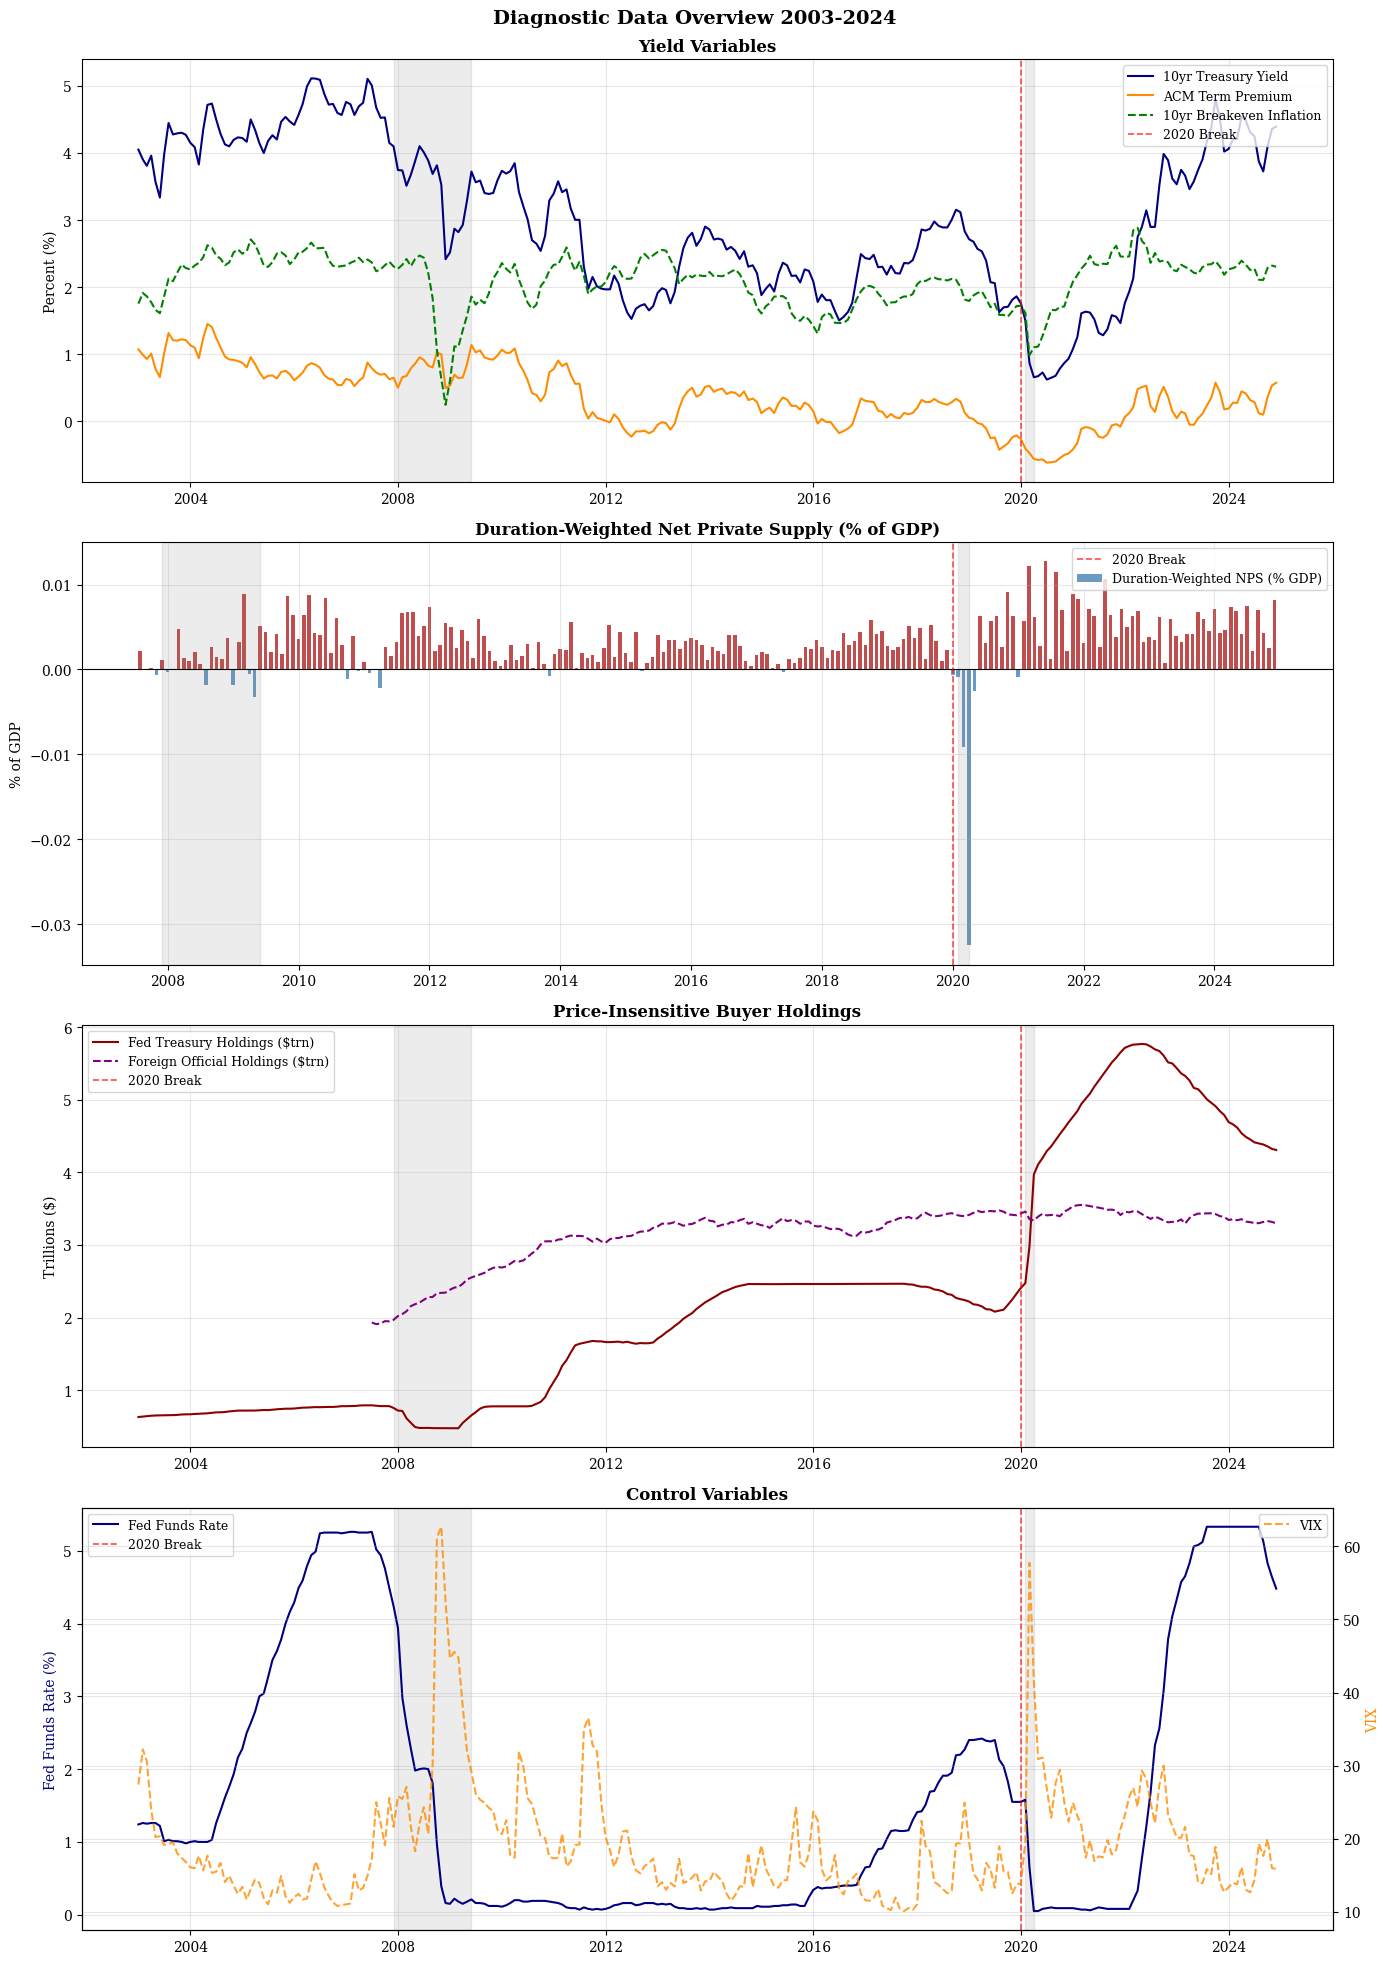

✓ Diagnostic plots saved to figures/01_diagnostic_overview.png


In [36]:
# =============================================================
# SECTION 7 — DIAGNOSTIC PLOTS
# =============================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set consistent style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.family'] = 'serif'

# Define recession shading dates for reference
# 2007-2009 GFC, 2020 COVID
recessions = [
    ('2007-12-01', '2009-06-01'),
    ('2020-02-01', '2020-04-01')
]

def add_recession_shading(ax):
    for start, end in recessions:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                  alpha=0.15, color='grey', label='_nolegend_')

# Add 2020 break line to all plots
def add_break_line(ax):
    ax.axvline(pd.Timestamp('2020-01-01'),
               color='red', linestyle='--',
               linewidth=1.2, alpha=0.7,
               label='2020 Break')

fig, axes = plt.subplots(4, 1, figsize=(14, 20))
fig.suptitle('Diagnostic Data Overview 2003-2024\n',
             fontsize=14, fontweight='bold', y=0.98)

# --- Plot 1: Yield Series ---
ax1 = axes[0]
ax1.plot(df_primary.index, df_primary['dgs10'],
         label='10yr Treasury Yield', color='navy', linewidth=1.5)
ax1.plot(df_primary.index, df_primary['term_premium'],
         label='ACM Term Premium', color='darkorange', linewidth=1.5)
ax1.plot(df_primary.index, df_primary['breakeven_10yr'],
         label='10yr Breakeven Inflation', color='green', linewidth=1.5,
         linestyle='--')
add_recession_shading(ax1)
add_break_line(ax1)
ax1.set_title('Yield Variables', fontweight='bold')
ax1.set_ylabel('Percent (%)')
ax1.legend(loc='upper right', fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# --- Plot 2: Net Private Supply ---
ax2 = axes[1]
ax2.bar(df_primary.index, df_primary['nps_dw_pct_gdp'],
        label='Duration-Weighted NPS (% GDP)',
        color=df_primary['nps_dw_pct_gdp'].apply(
            lambda x: 'firebrick' if x > 0 else 'steelblue'),
        width=20, alpha=0.8)
ax2.axhline(0, color='black', linewidth=0.8)
add_recession_shading(ax2)
add_break_line(ax2)
ax2.set_title('Duration-Weighted Net Private Supply (% of GDP)',
              fontweight='bold')
ax2.set_ylabel('% of GDP')
ax2.legend(loc='upper right', fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# --- Plot 3: Fed Balance Sheet and Foreign Holdings ---
ax3 = axes[2]
ax3.plot(df_primary.index, df_primary['fed_treasury_trn'],
         label='Fed Treasury Holdings ($trn)', color='darkred', linewidth=1.5)
ax3.plot(df_primary.index, df_primary['foreign_official_trn'],
         label='Foreign Official Holdings ($trn)', color='purple',
         linewidth=1.5, linestyle='--')
add_recession_shading(ax3)
add_break_line(ax3)
ax3.set_title('Price-Insensitive Buyer Holdings', fontweight='bold')
ax3.set_ylabel('Trillions ($)')
ax3.legend(loc='upper left', fontsize=9)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# --- Plot 4: Controls ---
ax4 = axes[3]
ax4_twin = ax4.twinx()
ax4.plot(df_primary.index, df_primary['fedfunds'],
         label='Fed Funds Rate', color='navy', linewidth=1.5)
ax4_twin.plot(df_primary.index, df_primary['vix'],
              label='VIX', color='darkorange', linewidth=1.5,
              linestyle='--', alpha=0.8)
add_recession_shading(ax4)
add_break_line(ax4)
ax4.set_title('Control Variables', fontweight='bold')
ax4.set_ylabel('Fed Funds Rate (%)', color='navy')
ax4_twin.set_ylabel('VIX', color='darkorange')
ax4.legend(loc='upper left', fontsize=9)
ax4_twin.legend(loc='upper right', fontsize=9)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('../figures/01_diagnostic_overview.png', dpi=150,
            bbox_inches='tight')
plt.show()

print("✓ Diagnostic plots saved to figures/01_diagnostic_overview.png")